# Analyze and results
Load rater data (give rathing.csv)


In [20]:
# Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import pingouin as pg
import os
import scipy.stats as stats

from scipy.stats import chi2
from plotly import express as px
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa



# Constants
RATERS_FILES = [  # Use a constant for file paths
    #'/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Documentations/QC/Evaluation/eye_qc_83/2_ratings/1_training_session/v1/ratings.csv',
    '/Users/cyriltelley/Library/CloudStorage/OneDrive-SharedLibraries-HESSO/Franceschiello Benedetta - 1_Cyril_Telley/QC/Evaluation/eye_qc_83/2_ratings/2_remaining_68/bene/ratings.csv',
    '/Users/cyriltelley/Library/CloudStorage/OneDrive-SharedLibraries-HESSO/Franceschiello Benedetta - 1_Cyril_Telley/QC/Evaluation/eye_qc_83/2_ratings/2_remaining_68/jaime/ratings.csv',
    '/Users/cyriltelley/Library/CloudStorage/OneDrive-SharedLibraries-HESSO/Franceschiello Benedetta - 1_Cyril_Telley/QC/Evaluation/eye_qc_83/2_ratings/2_remaining_68/meri/ratings.csv',
    #'/Users/cyriltelley/Library/CloudStorage/OneDrive-SharedLibraries-HESSO/Franceschiello Benedetta - 1_Cyril_Telley/QC/Evaluation/eye_qc_83/2_ratings/1_training_session/meri-bene-jaime/ratings.csv',
    #'/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Documentations/QC/Evaluation/eye_qc_83/2_ratings/1_training_session/v2/ratings.csv',
]

## Data Loading and Preprocessing Function


In [21]:
# Data Loading and Preprocessing Function
def load_and_preprocess_data(file_paths):
    """Loads, preprocesses, and combines rater data.

    Args:
        file_paths (list): A list of file paths to the rater CSV files.

    Returns:
        pandas.DataFrame: A single DataFrame containing all rater data.
    """
    all_data = []
    for rater_index, file in enumerate(file_paths):
        df = pd.read_csv(file)
        df['rater'] = f'Rater {rater_index + 1}'  # Add rater ID
        all_data.append(df)

    combined_df = pd.concat(all_data, ignore_index=True)
    combined_df['rating'] = (combined_df['rating1'] + combined_df['rating2']) / 2
    combined_df['sub'] = combined_df['sub'].astype(str)
    combined_df['rater'] = combined_df['rater'].astype('category')
    return combined_df

# Load the data
all_data = load_and_preprocess_data(RATERS_FILES)

## scatter plots - ggplot
Compare ratings between two .csv file

In [63]:
# --- Faceted Plot Function ---
def create_faceted_plots(metrics, raters_data):
    """Creates combined plots for multiple metrics across raters,
       displaying all raters on the same plot for each metric.
    """
    all_data = []

    for rater_index, df in enumerate(raters_data):
        for metric_name, metric_func in metrics.items():
            metric_data = metric_func(df)
            subjects = df['sub'].to_numpy() if 'sub' in df.columns else np.arange(len(metric_data))
            temp_df = pd.DataFrame({
                'Subject': subjects,
                'Value': metric_data,
                'Rater': f'Rater {rater_index + 1}',
                'Metric': metric_name  # Keep track of the metric
            })
            all_data.append(temp_df)

    merged_data = pd.concat(all_data, ignore_index=True)
    is_subject_numeric = all(isinstance(x, (int, float)) for x in merged_data['Subject'].unique())

    # Create separate plots for EACH METRIC (no faceting)
    for metric_name in metrics.keys():
        metric_df = merged_data[merged_data['Metric'] == metric_name]

        fig = px.histogram(
            metric_df,
            x='Subject',
            y='Value',
            color='Rater',
            barmode='group',
            title=f"Comparison of {metric_name} Across Raters",  # Specific title
            template="plotly_white",
        )

        # Customize hover data
        fig.update_traces(
            hovertemplate=(
                f"<b>Subject:</b> %{{x}}<br>"
                f"<b>Value:</b> %{{y}}<br>"
                #f"<b>Rater:</b> %{{text}}"
            ),
            text=metric_df['Rater']
        )
        
        # Set x-axis type based on subject data type
        if is_subject_numeric:
            fig.update_xaxes(type='linear')
        else:
            fig.update_xaxes(
                tickmode='array',
                tickvals=metric_df['Subject'].unique(),
                ticktext=metric_df['Subject'].unique()
            )

        fig.update_layout(legend_title="Rater")
        fig.show()  # Show each plot individually


# raters_data (DYNAMIC VERSION)
raters_data = [all_data[all_data['rater'] == rater] for rater in all_data['rater'].unique()]

# Define metrics
metrics = {
    'Rating': lambda df: np.mean([df['rating1'].to_numpy(), df['rating2'].to_numpy()], axis=0),
    'Rating 1': lambda df: df['rating1'].to_numpy(),
    'Rating 2': lambda df: df['rating2'].to_numpy(),
    'Blur': lambda df: df['blur'].to_numpy(),
    'Noise': lambda df: df['noise'].to_numpy(),
    'Motion': lambda df: df['motion'].to_numpy(),
    'BgAir': lambda df: df['bgair'].to_numpy(),
    'Eyes Closed': lambda df: np.where(df['artifacts'].to_numpy() == "['eyes-open']", 1, 0),
}

create_faceted_plots(metrics, raters_data)

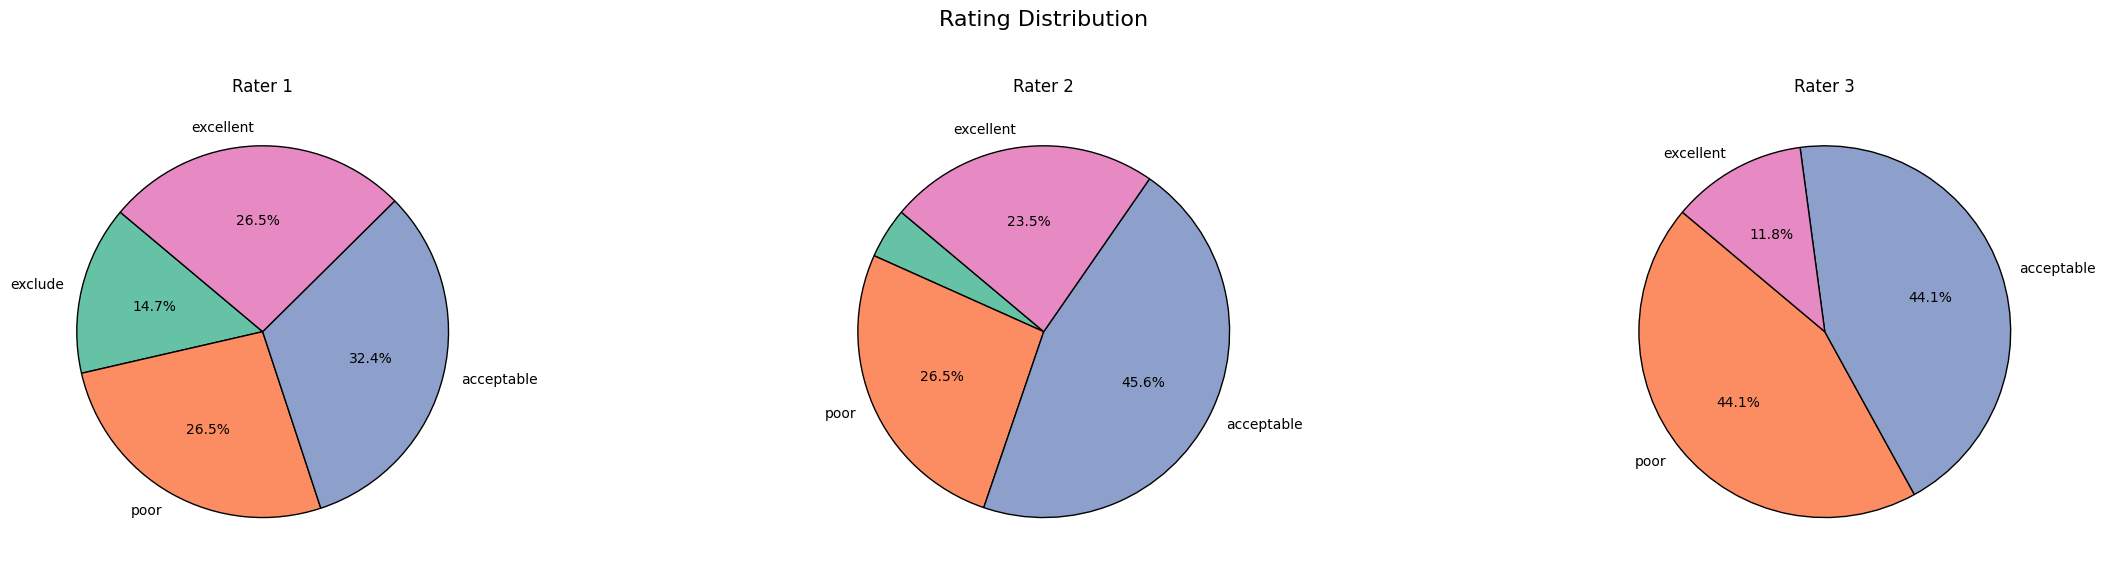

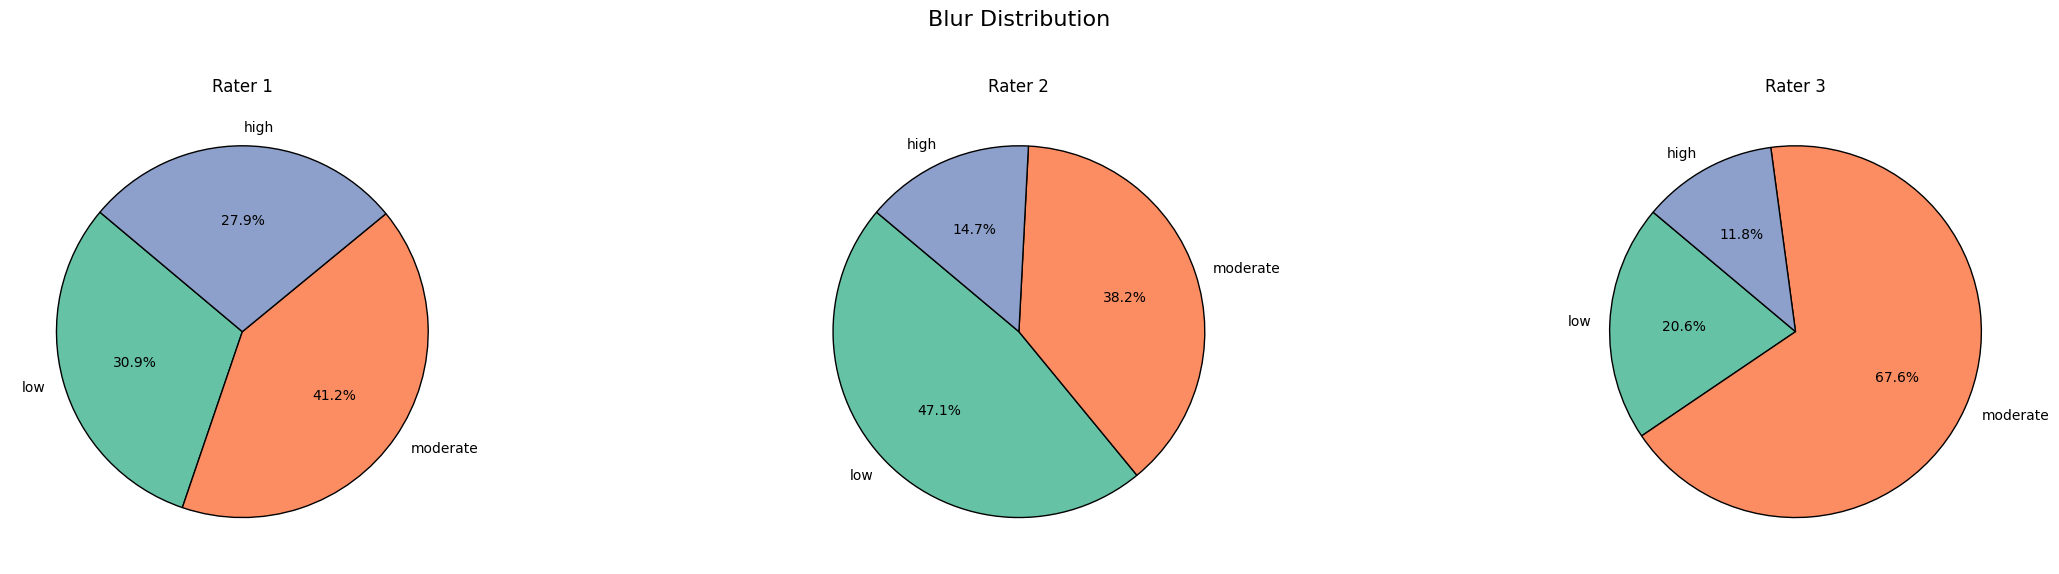

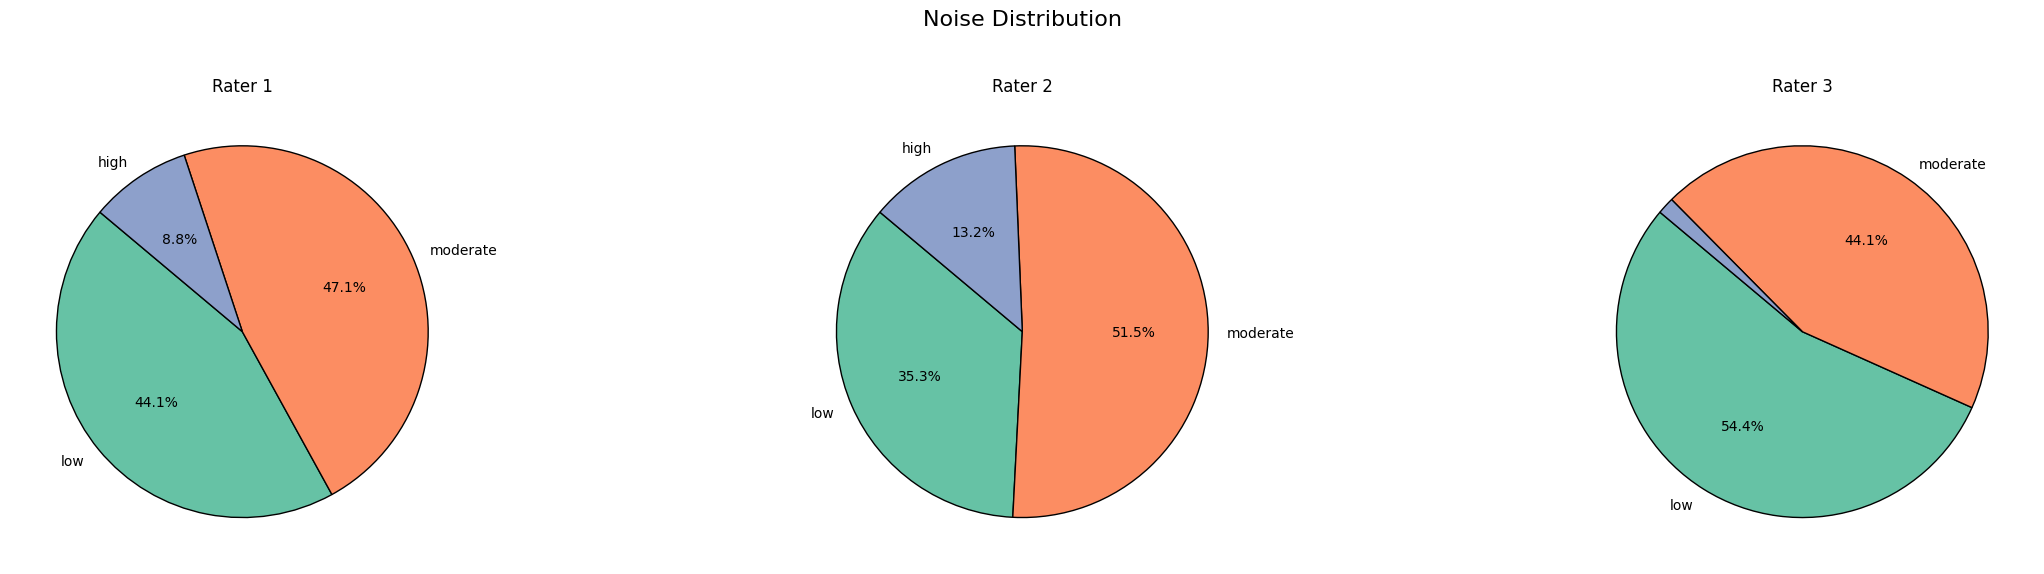

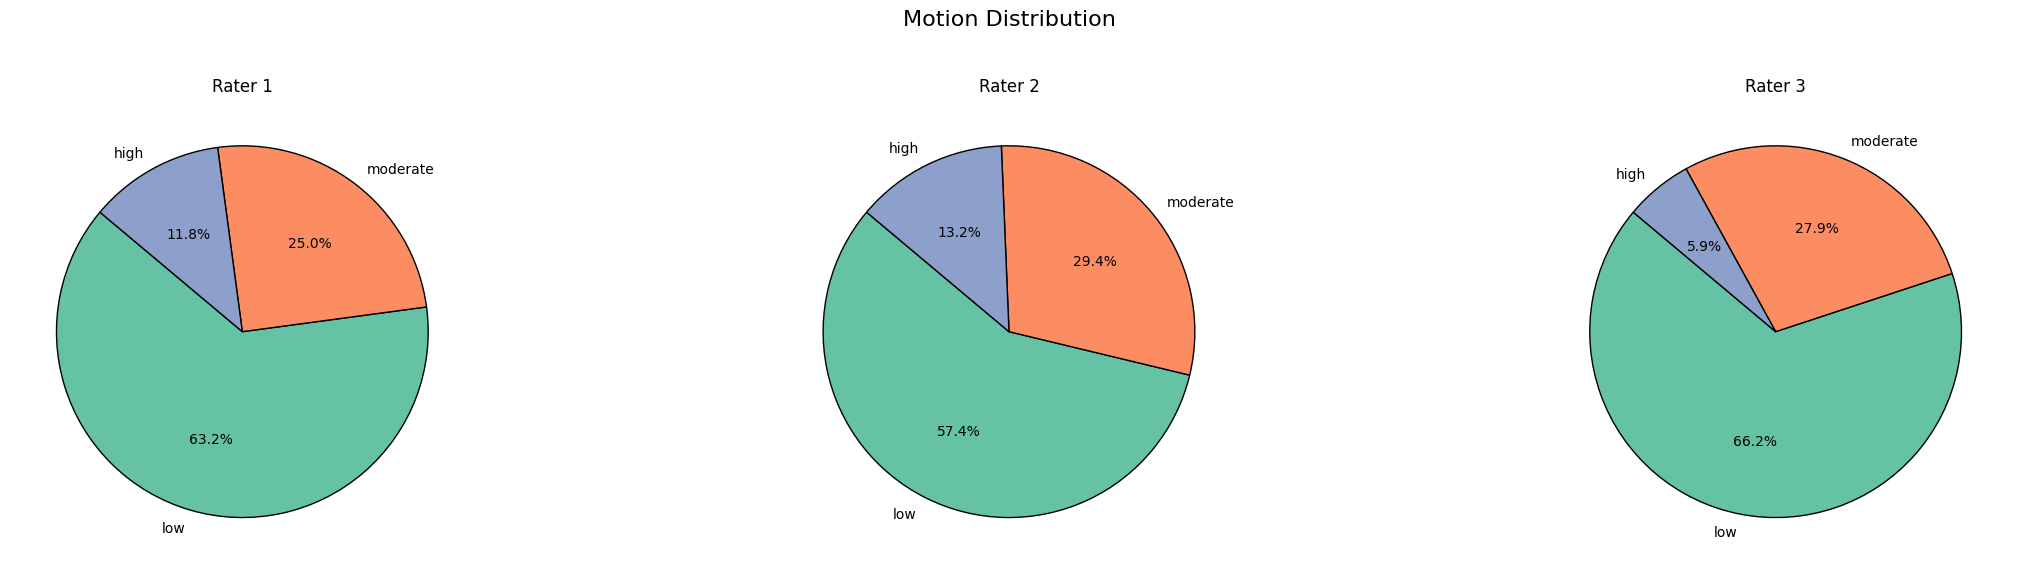

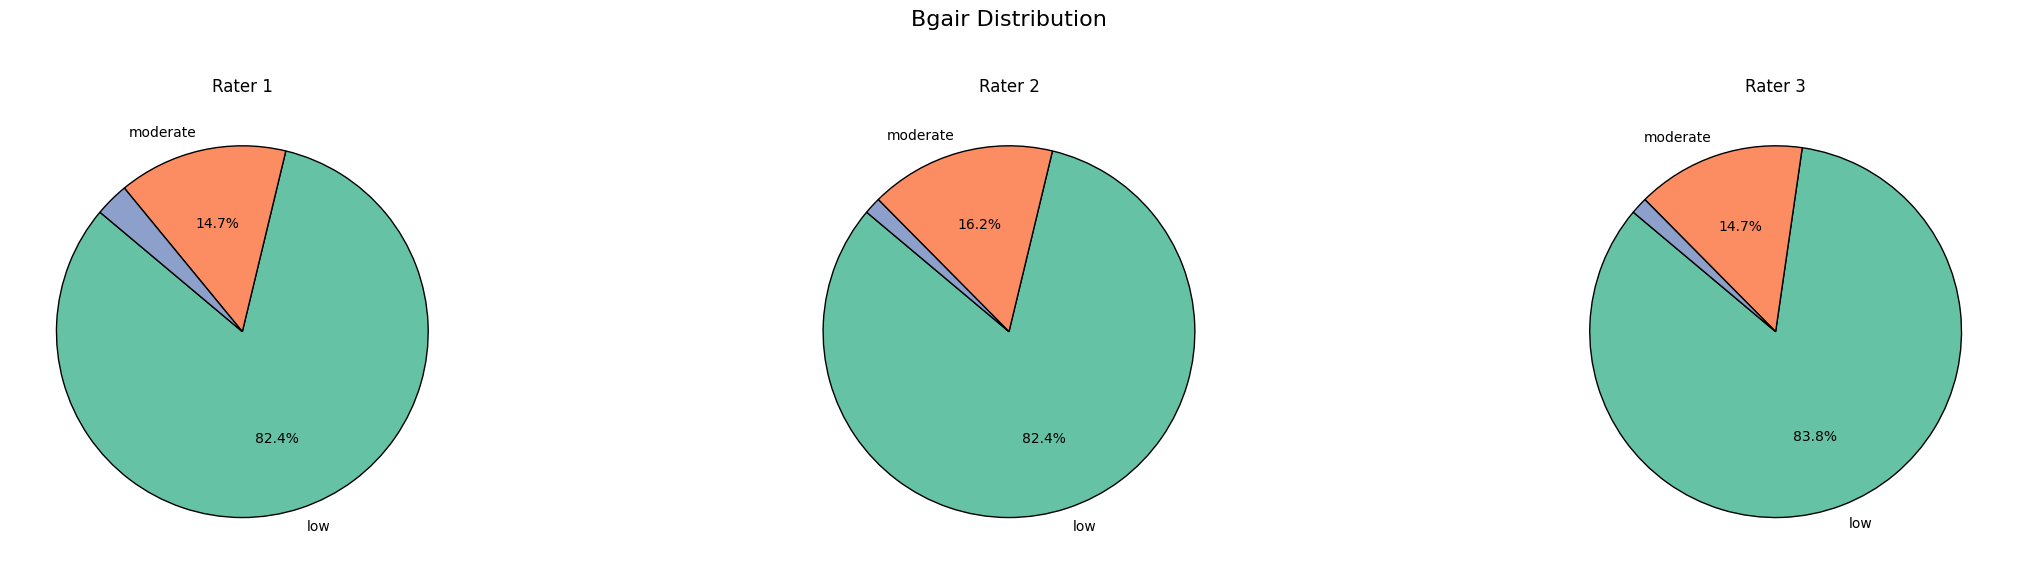

In [37]:

# --- Pie Plot Function ---
def pie_plot(metrics, raters_data):
    """
    Generates pie charts for each metric, with one chart per rater,
    using consistent colors and label filtering.
    """

    # Colors for 4 and 3 categories (more homogeneous palette)
    colors_map = {
        4: ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'],
        3: ['#66c2a5', '#fc8d62', '#8da0cb']
    }

    # Threshold below which labels are not displayed
    LABEL_THRESHOLD = 5  # Percent

    # Generate pie charts for each metric
    for metric_name, categories in metrics.items():
        num_categories = len(categories)
        colors = colors_map.get(num_categories, ['gray'] * num_categories)  # Default to gray if not 3 or 4

        # Create a single figure for all raters for this metric
        fig, axes = plt.subplots(1, len(raters_data), figsize=(8 * len(raters_data), 6))

        # Handle the case where there's only one rater (axes becomes a single AxesSubplot, not a list)
        if len(raters_data) == 1:
            axes = [axes]

        for i, rater_df in enumerate(raters_data):
            # Count occurrences of each category, ensuring ALL categories are counted
            counts = []
            for cat in categories:
                if metric_name in rater_df.columns:
                    count = rater_df[metric_name].to_list().count(cat)
                else:
                    count = 0  # Handle missing column
                counts.append(count)

            total = sum(counts)
            percentages = [(count / total) * 100 for count in counts] if total > 0 else [0] * len(counts)

            # Filter labels below threshold
            filtered_labels = [
                f"{categories[idx]}" if percentages[idx] >= LABEL_THRESHOLD else ""
                for idx in range(len(categories))
            ]

            # Create the pie chart
            axes[i].pie(
                percentages,  # Use percentages directly for consistent sizing
                labels=filtered_labels,
                autopct=lambda p: f'{p:.1f}%' if p >= LABEL_THRESHOLD else '',
                startangle=140,
                colors=colors,
                wedgeprops={'edgecolor': 'black'}
            )
            axes[i].set_title(f'Rater {i + 1}')
            axes[i].set_aspect('equal')

        # Add a title to the entire figure
        fig.suptitle(f'{metric_name.replace("_text", "").capitalize()} Distribution', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for suptitle
        plt.show()

# Define metrics and categories
metrics = {
    'rating_text': ['exclude', 'poor', 'acceptable', 'excellent'],
    'blur_text': ['low', 'moderate', 'high'],
    'noise_text': ['low', 'moderate', 'high'],
    'motion_text': ['low', 'moderate', 'high'],
    'bgair_text': ['low', 'moderate', 'high']
}

# raters_data (DYNAMIC VERSION)
raters_data = [all_data[all_data['rater'] == rater] for rater in all_data['rater'].unique()]

pie_plot(metrics, raters_data)

## Mixed-Effects Model Function


In [43]:
# Mixed-Effects Model Function
def fit_mixed_model(data, formula, groups, re_formula=None):
    """Fits a linear mixed-effects model.

    Args:
        data (pd.DataFrame): The input DataFrame.
        formula (str): The model formula (e.g., "rating ~ blur + noise").
        groups (str): The grouping variable for random intercepts (e.g., "sub").
        re_formula (str, optional): Random effects formula. Defaults to None.

    Returns:
        statsmodels.regression.mixed_linear_model.MixedLMResults: Fitted model results.
        Or None if the model fails to converge
    """
    try:
        model = smf.mixedlm(formula, data=data, groups=groups, re_formula=re_formula)
        result = model.fit()
        return result
    except Exception as e:
        print(f"Error fitting mixed model: {e}")
        return None

def likelihood_ratio_test(result_full, result_reduced):
    """Performs a likelihood ratio test between two nested models.

    Args:
        result_full (MixedLMResults): Results of the full model.
        result_reduced (MixedLMResults): Results of the reduced model.

    Returns:
        tuple: (lrt_statistic, p_value) or (None, None) if either result is None
    """
    if result_full is None or result_reduced is None:
        print("Cannot perform LRT: One or both models are None.")
        return None, None

    lrt = 2 * (result_full.llf - result_reduced.llf)
    # Corrected degrees of freedom calculation:
    df_diff = result_full.df_modelwc - result_reduced.df_modelwc  # Use df_modelwc
    p_value = chi2.sf(lrt, df_diff)  # Degrees of freedom based on model complexity difference
    return lrt, p_value

## Model Fitting and Selection (Linear Mixed-Effects Model)

**Model Type:** Linear Mixed-Effects Model (also known as a hierarchical model or multilevel model)

**Why Mixed-Effects?**

*   **Multiple Raters:** We have data from multiple raters evaluating the same subjects. Raters might have inherent differences in their rating tendencies (some might be stricter, some more lenient). A mixed-effects model accounts for this variability.
*   **Multiple Subjects:** We have multiple subjects (images being rated). Subjects also have inherent differences in their overall quality, independent of the artifacts.

**Mathematical Representation :**
```
Rating_ijk = β0 + β1*Blur_ijk + β2*Noise_ijk + β3*Motion_ijk + β4*BgAir_ijk + b_i + c_j + d_ij + ε_ijk
```

**Where:**

*   **`Rating_ijk`**: The rating given to subject *i* by rater *j* on image/video instance *k*. Note: your model output doesn't explicitly show an index *k*, so it seems that you have one observation per subject-rater.
*   **`β0`**: The *fixed-effect* intercept.  This is the estimated average rating when all predictors are zero. In your output: `Intercept = 3.234`.
*   **`β1`, `β2`, `β3`, `β4`**: The *fixed-effect* coefficients (slopes) for `blur`, `noise`, `motion`, and `bgair`.  These are interpreted the same way as before: the change in rating for a one-unit increase in the predictor, *holding all other variables constant*. In your output:
    *   `blur = -0.345`
    *   `noise = -0.291`
    *   `motion = -0.331`
    *   `bgair = -0.091`
*   **`Blur_ijk`, `Noise_ijk`, `Motion_ijk`, `BgAir_ijk`**: The observed values of the predictor variables.
*   **`b_i`**: The *random intercept* for subject *i*. This captures the inherent variability in overall quality *between subjects*.  Each subject has its own `b_i`, drawn from a normal distribution with mean 0 and variance estimated by the model. In your output: `sub Var = 0.229`. This is the *variance* of the subject random intercepts.
* **`c_j`**: This represents the main random effect of the rater j. Each rater have it's own `c_j`, drawn from a normal distribution with a mean of 0 and a variance estimated by the model.
* **`d_ij`**: Represents the random interaction between the subject i and the rater j. Each combination of subject i and rater j has his own `d_ij`, drawn from a normal distribution with a mean of 0.
*   **`ε_ijk`**: The residual (error term).  This is the unexplained variation in the rating, *after* accounting for the fixed effects and the random effects. It's assumed to be normally distributed with mean 0 and constant variance. In your output: `Scale = 0.0557`. This is the *variance* of the residuals.



--- Trying Full Model (with Rater RE) ---


/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning:

Retrying MixedLM optimization with lbfgs



                      Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          rating   
No. Observations:          204              Method:                      REML     
No. Groups:                68               Scale:                       0.0557   
Min. group size:           3                Log-Likelihood:              -135.2214
Max. group size:           3                Converged:                   Yes      
Mean group size:           3.0                                                    
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                3.234    0.108 29.820 0.000  3.022  3.447
blur                                    -0.345    0.058 -5.908 0.000 -0.460 -0.231
noise                      

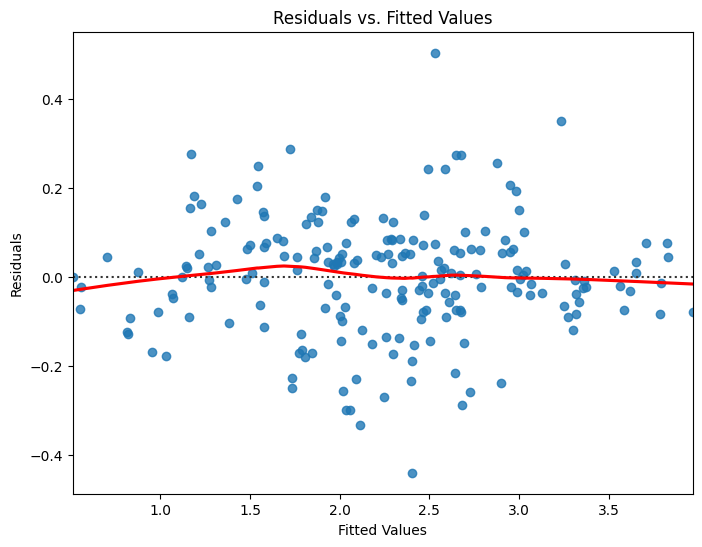

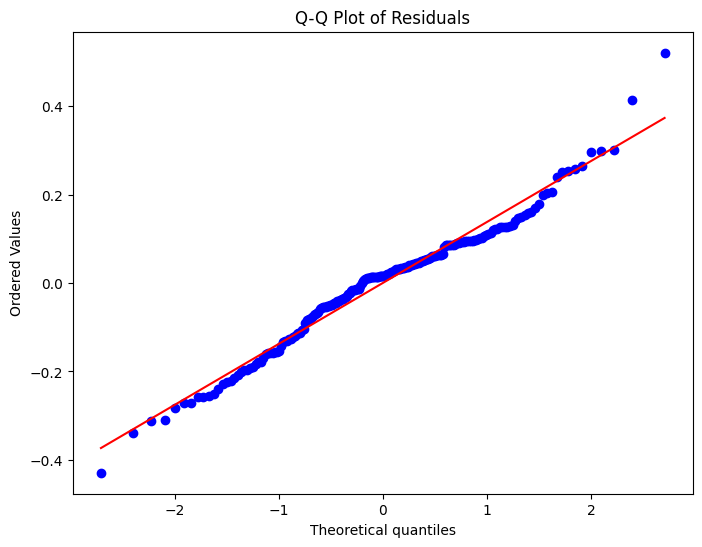

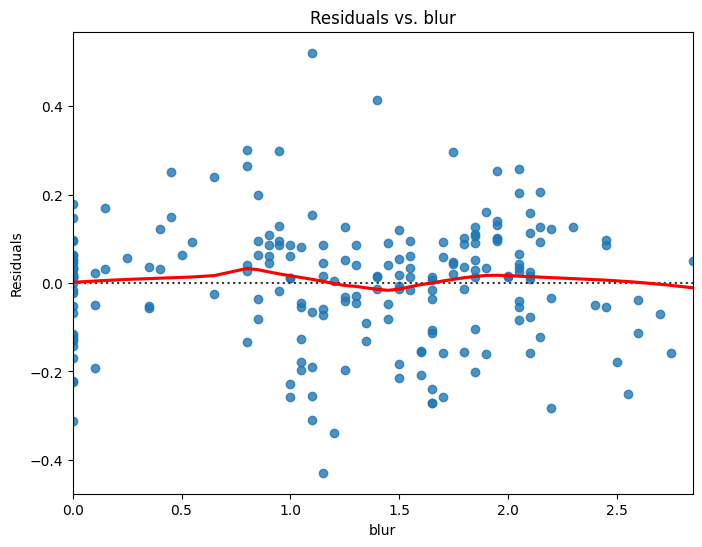

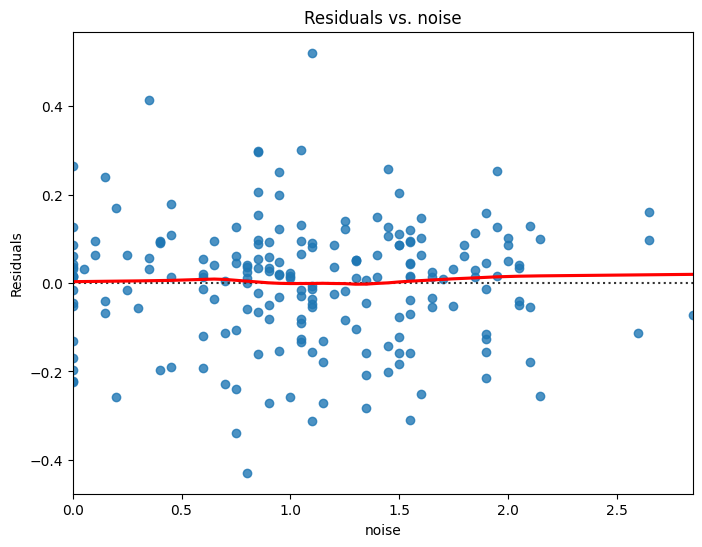

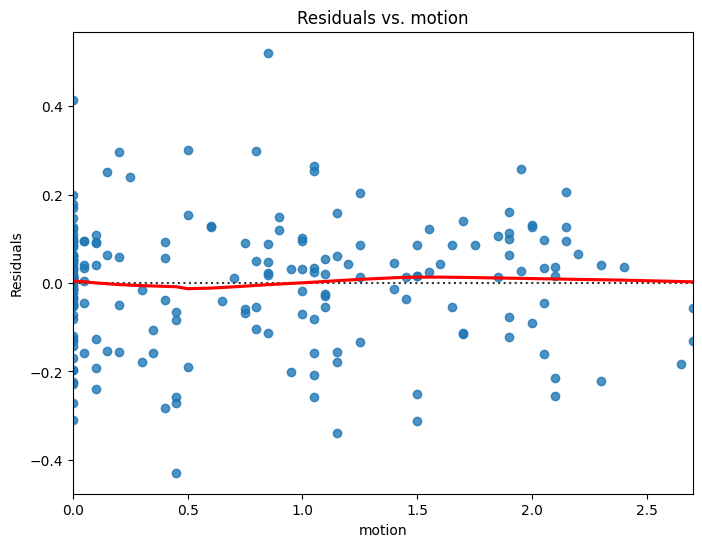

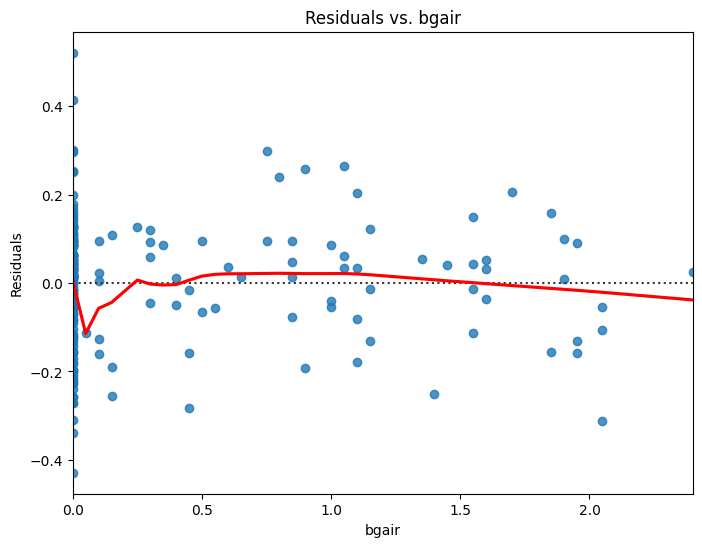

In [ ]:
# --- Model Fitting and Comparison Linear Mixed-Effects Model---
# Full Model
print("--- Trying Full Model (with Rater RE) ---")

# Use the fit_mixed_model function
result_full = fit_mixed_model(all_data, "rating ~ blur + noise + motion + bgair", groups="sub", re_formula="~rater")

if result_full is not None:
    print(result_full.summary())
    full_model_converged = True  
else:
    full_model_converged = False


# 2. Simplified Model (no rater random effect) - Always fit this for comparison
print("\n--- Trying Simplified Model (No Rater RE) ---")
# Use the fit_mixed_model function (without re_formula)
result_simple = fit_mixed_model(all_data, "rating ~ blur + noise + motion + bgair", groups="sub")

if result_simple is not None:
    print(result_simple.summary())


# 3. Likelihood Ratio Test (ONLY if the full model converged AND simplified model converged)
if full_model_converged and result_simple is not None:
    lrt, p_value = likelihood_ratio_test(result_full, result_simple)
    if lrt is not None:  # Check if LRT was successful
        print(f"\nLikelihood Ratio Test: LRT = {lrt:.3f}, p-value = {p_value:.4f}")

        # Choose the best model based on LRT AND convergence
        if p_value > 0.05:
            print("\nUse the simplified model (no rater random effect).")
            final_model = result_simple
        else:
            print("\nUse the full model (with rater random effect).")
            final_model = result_full
    else:
        print("\nLRT failed. Using simplified model.")
        final_model = result_simple # Use simplified model if LRT failed
elif result_simple is not None:  # Simplified model converged, but full didn't
    print("\nFull model did not converge. Using simplified model.")
    final_model = result_simple  # Use the simplified model if the full model failed
else: # Neither model converged
    print("\nNeither model converged. No final model available.")
    final_model = None

if final_model is not None:
    print("\n--- Final Model Summary ---")
    print(final_model.summary())

    # --- Interpretation and Predominant Artifact(s) ---
    print("\n--- Interpretation and Predominant Artifact(s) ---")

    significant_artifacts = []
    for name, pval in final_model.pvalues.items():
        if name in ['blur', 'noise', 'motion', 'bgair'] and pval < 0.05:
            significant_artifacts.append((name, final_model.params[name]))

    if significant_artifacts:
        significant_artifacts.sort(key=lambda x: abs(x[1]), reverse=True)
        print("Significant artifacts (in order of influence):")
        for name, coef in significant_artifacts:
            print(f"  - {name}: Coefficient = {coef:.3f}")
        predominant_artifact = significant_artifacts[0][0]
        print(f"\nThe predominant artifact is: {predominant_artifact}")
    else:
        print("No artifacts have a statistically significant effect on rating.")

    # --- Model Diagnostics (for the final model) ---
    # Residuals vs. Fitted Values
    plt.figure(figsize=(8, 6))
    sns.residplot(x=final_model.fittedvalues, y=final_model.resid, lowess=True, line_kws={'color': 'red'})
    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs. Fitted Values")
    plt.show()

    # Q-Q Plot of Residuals
    plt.figure(figsize=(8, 6))
    stats.probplot(final_model.resid, dist="norm", plot=plt)
    plt.title("Q-Q Plot of Residuals")
    plt.show()

    # Residuals vs. Predictors
    for predictor in ['blur', 'noise', 'motion', 'bgair']:
        if predictor in all_data.columns:  # Check if predictor exists
            plt.figure(figsize=(8, 6))
            sns.residplot(x=all_data[predictor], y=final_model.resid, lowess=True, line_kws={'color': 'red'})
            plt.xlabel(predictor)
            plt.ylabel("Residuals")
            plt.title(f"Residuals vs. {predictor}")
            plt.show()
        else:
            print(f"Predictor '{predictor}' not found in data. Skipping plot.")
else:
    print("\nNo final model available for diagnostics.")


Within-Subject, Within-Rater Standard Deviations:
    sub    rater  rating
0     1  Rater 1     NaN
1     1  Rater 2     NaN
2     1  Rater 3     NaN
3    10  Rater 1     NaN
4    10  Rater 2     NaN
..   ..      ...     ...
199  83  Rater 2     NaN
200  83  Rater 3     NaN
201   9  Rater 1     NaN
202   9  Rater 2     NaN
203   9  Rater 3     NaN

[204 rows x 3 columns]

Mean of within-subject, within-rater standard deviations: nan


/var/folders/65/_6_vzrxd7ql89tvbx49tn3rr0000gn/T/ipykernel_3538/3378550215.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/65/_6_vzrxd7ql89tvbx49tn3rr0000gn/T/ipykernel_3538/3378550215.py:36: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



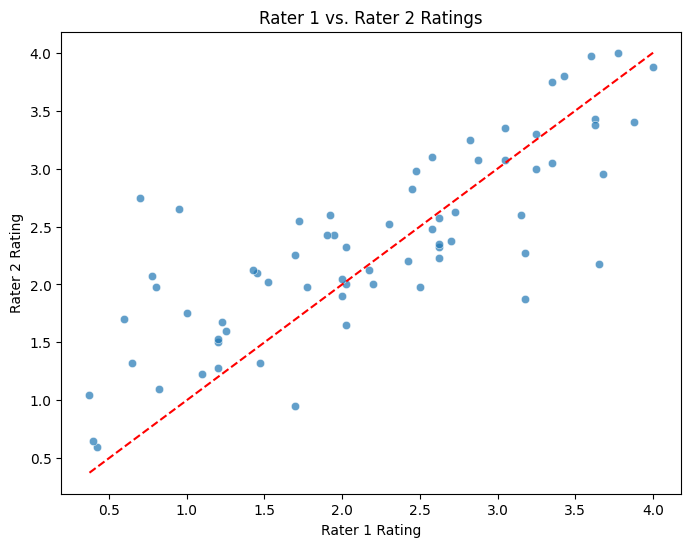

/var/folders/65/_6_vzrxd7ql89tvbx49tn3rr0000gn/T/ipykernel_3538/3378550215.py:36: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



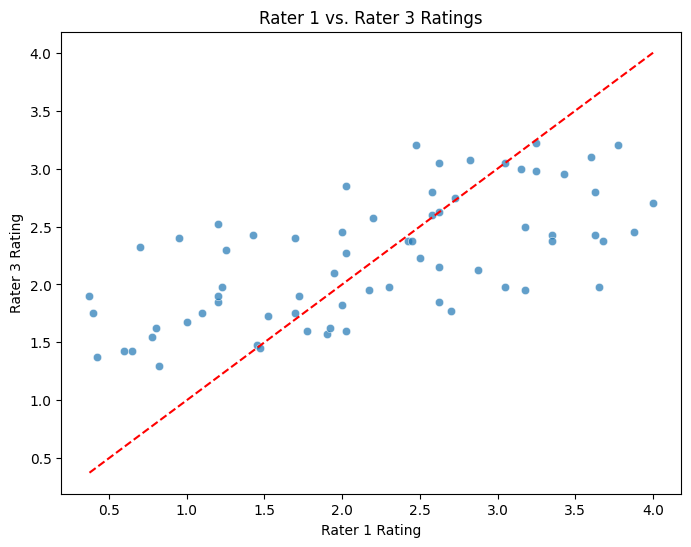

/var/folders/65/_6_vzrxd7ql89tvbx49tn3rr0000gn/T/ipykernel_3538/3378550215.py:36: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



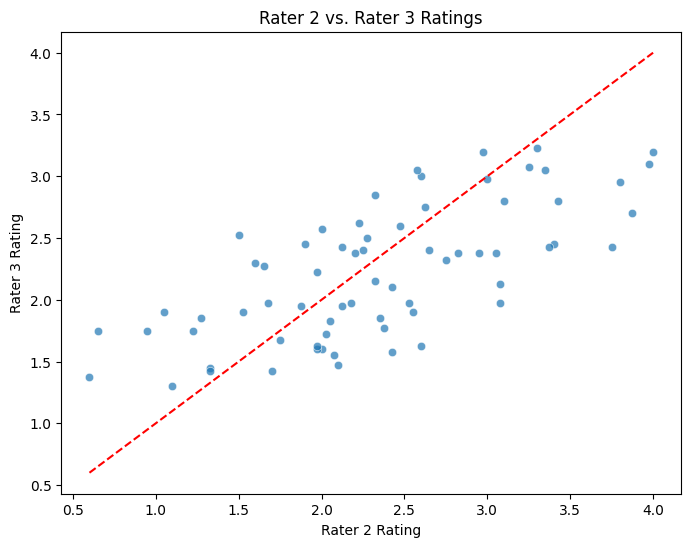


Subjects where raters gave identical ratings:
Empty DataFrame
Columns: [sub, rating]
Index: []

Summary Statistics of Artifacts:
             blur       noise      motion       bgair
count  204.000000  204.000000  204.000000  204.000000
mean     1.245098    1.081863    0.736275    0.333578
std      0.764048    0.631102    0.780162    0.594608
min      0.000000    0.000000    0.000000    0.000000
25%      0.800000    0.700000    0.000000    0.000000
50%      1.325000    1.050000    0.450000    0.000000
75%      1.850000    1.550000    1.250000    0.450000
max      2.850000    2.850000    2.700000    2.400000


In [ ]:


def perform_diagnostic_checks(all_data):
    """Performs diagnostic checks on the rater data.

    Args:
        all_data (pd.DataFrame): The combined rater data.
    """

    # 1. Within-Subject, Within-Rater Standard Deviation
    std_devs = all_data.groupby(['sub', 'rater'])['rating'].std().reset_index()
    print("\nWithin-Subject, Within-Rater Standard Deviations:")
    print(std_devs)
    print("\nMean of within-subject, within-rater standard deviations:", std_devs['rating'].mean())

    # 2. Visualize with Scatter Plots (Improved with Seaborn and dynamic rater handling)
    raters = all_data['rater'].unique()
    if len(raters) > 1:  # Only create scatter plots if there's more than one rater
        for i in range(len(raters)):
            for j in range(i + 1, len(raters)):
                rater1 = raters[i]
                rater2 = raters[j]

                # Create a pivot table for the two raters
                pivot_data = all_data[all_data['rater'].isin([rater1, rater2])].pivot_table(
                    index='sub', columns='rater', values='rating'
                ).dropna()

                plt.figure(figsize=(8, 6))
                sns.scatterplot(x=rater1, y=rater2, data=pivot_data, alpha=0.7)  # Use seaborn
                plt.xlabel(f"{rater1} Rating")
                plt.ylabel(f"{rater2} Rating")
                plt.title(f"{rater1} vs. {rater2} Ratings")

                # Add a diagonal line for perfect agreement
                min_val = min(pivot_data[rater1].min(), pivot_data[rater2].min())
                max_val = max(pivot_data[rater1].max(), pivot_data[rater2].max())
                plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
                plt.show()

    #3. Check perfect agreement
    agreements = all_data.groupby('sub')['rating'].apply(lambda x: x.nunique() == 1).reset_index()
    print("\nSubjects where raters gave identical ratings:")
    print(agreements[agreements['rating']==True])

    # 4. Check numerical values of artifacts:
    print("\nSummary Statistics of Artifacts:")
    print(all_data[['blur', 'noise', 'motion', 'bgair']].describe())

# --- Call the function with your data ---
raters_data = []
for rater_index, file in enumerate(RATERS_FILES):
    df = pd.read_csv(file)
    df['rater'] = f'Rater {rater_index + 1}'
    raters_data.append(df)
all_data = pd.concat(raters_data, ignore_index=True)

all_data['rating'] = (all_data['rating1'] + all_data['rating2']) / 2
all_data['sub'] = all_data['sub'].astype(str)
all_data['rater'] = all_data['rater'].astype('category')

perform_diagnostic_checks(all_data)

## Correlation Matrix

correlation matrix

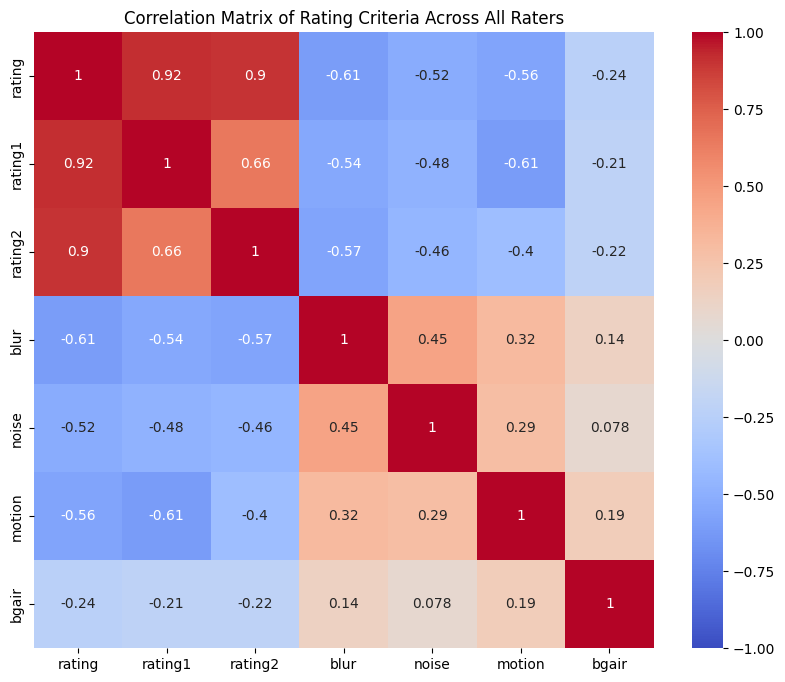

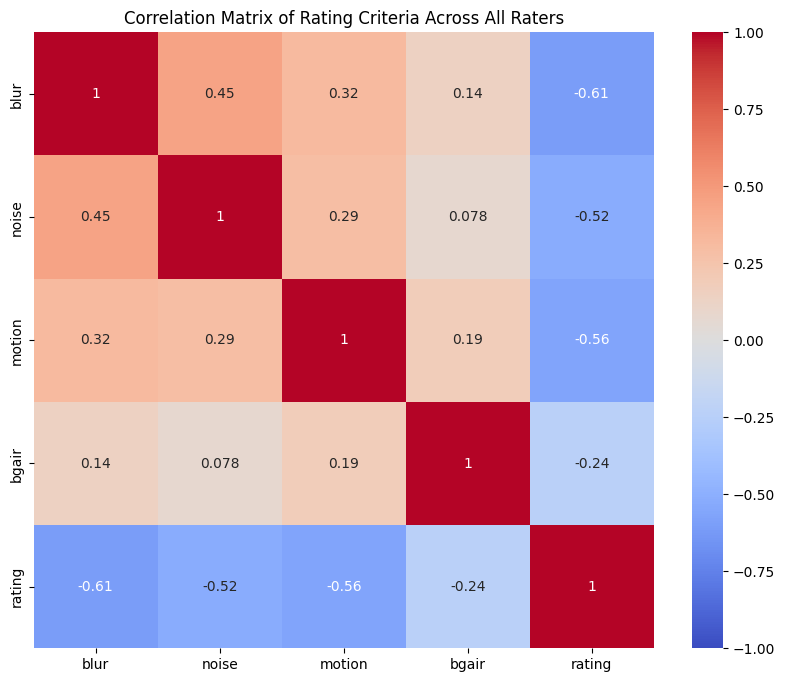

In [ ]:
# --- Correlation Matrix ---
def plot_correlation_matrix(raters_files, metrics_names):
    """
    Calculates and plots the correlation matrix for rating criteria across all raters.
    Dynamically handles any number of raters.  Correctly handles NaNs.
    Args:
        raters_files (list): A list of file paths to the rater CSV files.
        metrics_names (list): List of column names to include in the correlation.
    """
    raters_data = []
    for rater_index, file in enumerate(raters_files):
        df = pd.read_csv(file)
        df['rater'] = f'Rater {rater_index + 1}'  # Add rater ID
        raters_data.append(df)

    combined_data = pd.concat(raters_data, ignore_index=True)

    # --- Data Preprocessing ---
    combined_data['rating'] = (combined_data['rating1'] + combined_data['rating2']) / 2
    combined_data['sub'] = combined_data['sub'].astype(str)
    combined_data['rater'] = combined_data['rater'].astype('category')

    # Select the rating criteria columns AND DROP ROWS WITH NANs
    correlation_data = combined_data[metrics_names].dropna()

    if not correlation_data.empty:
        # Compute the correlation matrix
        correlation_matrix = correlation_data.corr()

        # Plot the correlation matrix
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
        plt.title('Correlation Matrix of Rating Criteria Across All Raters')
        plt.show()
    else:
        print("Not enough data to create a correlation matrix after handling missing values.")

plot_correlation_matrix(RATERS_FILES, ['rating', 'rating1', 'rating2', 'blur', 'noise', 'motion', 'bgair'])
plot_correlation_matrix(RATERS_FILES, ['blur', 'noise', 'motion', 'bgair', 'rating'])

ICC(A,1) + Cohen's Kappa (for 2 raters)

* ICC(A,1) is sensitive to individual rater differences and can be misleading when many 0s dominate

* Cohen's Kappa measures the agreement on binary sets

In [31]:
# Load data for all raters
raters_data = [pd.read_csv(file) for file in RATERS_FILES]

# Metrics names
metrics_names = ['rating', 'rating1', 'rating2', 'blur', 'noise', 'motion', 'bgair']

# Combine data into a long-format DataFrame for ICC computation
def prepare_icc_data(metric_name):
    data = []
    for rater_idx, rater in enumerate(raters_data):
        for subject_idx, value in enumerate(rater[metric_name].to_numpy()):
            data.append([subject_idx, rater_idx, value])
    return pd.DataFrame(data, columns=['subject', 'rater', 'rating'])

# Compute ICC(A,1) and Cohen's Kappa for numeric metrics
for metric_name in metrics_names:
    # ICC(A,1)
    df_icc = prepare_icc_data(metric_name)
    icc_results = pg.intraclass_corr(data=df_icc, targets='subject', raters='rater', ratings='rating')
    icc_a1_row = icc_results.set_index("Type").loc["ICC2"]  # ICC(A,1) corresponds to ICC2 in pingouin
    icc_a1 = icc_a1_row["ICC"]
    ci_low, ci_high = icc_a1_row["CI95%"]  # Extract confidence interval tuple
    print(f"\nMetric: {metric_name} - ICC(A,1): {icc_a1:.3f} [{ci_low:.3f}, {ci_high:.3f}] CI95%")
    
    # Cohen's Kappa
    binary_data = [np.where(rater[metric_name].to_numpy() > 0, 1, 0) for rater in raters_data] # Convert each rater's ratings to binary (0 = absent, 1+ = present)
    for i in range(len(binary_data)):
        for j in range(i + 1, len(binary_data)):
            kappa = cohen_kappa_score(binary_data[i], binary_data[j])
            if np.isnan(kappa):
                print(f"Metric: {metric_name} - Cohen's Kappa Rater {i+1} vs Rater {j+1}: all non-zero ratings (NaN)")
            else:
                print(f"Metric: {metric_name} - Cohen's Kappa Rater {i+1} vs Rater {j+1}: {kappa:.3f}")

# Compute agreement for "eyes_open" (categorical metric)
eyes_open_data = [np.where(rater['artifacts'].to_numpy() == "['eyes-open']", 1, 0) for rater in raters_data]
total_cases = len(eyes_open_data[0])

agreement_count = sum(
    all(values[0] == v for v in values) for values in zip(*eyes_open_data)
)

print(f"\nEyes open agreement: {np.round(agreement_count / total_cases * 100, 2)}% of cases")



Metric: rating - ICC(A,1): 0.660 [0.540, 0.760] CI95%
Metric: rating - Cohen's Kappa Rater 1 vs Rater 2: all non-zero ratings (NaN)
Metric: rating - Cohen's Kappa Rater 1 vs Rater 3: all non-zero ratings (NaN)
Metric: rating - Cohen's Kappa Rater 2 vs Rater 3: all non-zero ratings (NaN)

Metric: rating1 - ICC(A,1): 0.728 [0.630, 0.810] CI95%
Metric: rating1 - Cohen's Kappa Rater 1 vs Rater 2: 0.000
Metric: rating1 - Cohen's Kappa Rater 1 vs Rater 3: all non-zero ratings (NaN)
Metric: rating1 - Cohen's Kappa Rater 2 vs Rater 3: 0.000

Metric: rating2 - ICC(A,1): 0.535 [0.400, 0.660] CI95%
Metric: rating2 - Cohen's Kappa Rater 1 vs Rater 2: all non-zero ratings (NaN)
Metric: rating2 - Cohen's Kappa Rater 1 vs Rater 3: all non-zero ratings (NaN)
Metric: rating2 - Cohen's Kappa Rater 2 vs Rater 3: all non-zero ratings (NaN)

Metric: blur - ICC(A,1): 0.316 [0.170, 0.470] CI95%
Metric: blur - Cohen's Kappa Rater 1 vs Rater 2: 0.050
Metric: blur - Cohen's Kappa Rater 1 vs Rater 3: -0.026
Met

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning:

A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:758: RuntimeWarning:

invalid value encountered in scalar divide

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning:

A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:758: RuntimeWarning:

invalid value encountered in scalar 

ICC(A,k) + Fleiss' Kappa (for >2 raters)

* ICC(A,k) accounts for multiple raters and gives a more stable estimate of agreement

* Fleiss' Kappa replaces Cohen's for multi-rater agreement

In [32]:

# Load data for all raters
raters_data = [pd.read_csv(file) for file in RATERS_FILES]

# Metrics names
metrics_names = ['rating', 'rating1', 'rating2', 'blur', 'noise', 'motion', 'bgair']

# Combine data into a long-format DataFrame for ICC computation
def prepare_icc_data(metric_name):
    data = []
    for rater_idx, rater in enumerate(raters_data):
        for subject_idx, value in enumerate(rater[metric_name].to_numpy()):
            data.append([subject_idx, rater_idx, value])
    return pd.DataFrame(data, columns=['subject', 'rater', 'rating'])

# Compute ICC(A,k) and Fleiss' Kappa for numeric metrics
for metric_name in metrics_names:
    # ICC(A,k)
    df_icc = prepare_icc_data(metric_name)
    icc_results = pg.intraclass_corr(data=df_icc, targets='subject', raters='rater', ratings='rating')
    icc_a1_row = icc_results.set_index("Type").loc["ICC2k"]  # Use ICC(A,k) instead of ICC(A,1)
    icc_a1 = icc_a1_row["ICC"]
    ci_low, ci_high = icc_a1_row["CI95%"]
    print(f"\nMetric: {metric_name} - ICC(A,k): {icc_a1:.3f} [{ci_low:.3f}, {ci_high:.3f}] CI95%")

    # Convert ratings to binary (0 = absent, 1+ = present)
    binary_data = [np.where(rater[metric_name].to_numpy() > 0, 1, 0) for rater in raters_data]

    # Construct contingency table for Fleiss' Kappa
    num_subjects = len(binary_data[0])  # Number of items rated
    num_raters = len(binary_data)       # Number of raters
    category_counts = np.zeros((num_subjects, 2))  # Two categories: 0 (absent), 1 (present)

    for subject_idx in range(num_subjects):
        for rater_idx in range(num_raters):
            category_counts[subject_idx, binary_data[rater_idx][subject_idx]] += 1

    # Compute Fleiss' Kappa
    kappa_fleiss = fleiss_kappa(category_counts)
    print(f"Metric: {metric_name} - Fleiss' Kappa: {kappa_fleiss:.3f}")

# Compute agreement for "eyes_open" (categorical metric)
eyes_open_data = [np.where(rater['artifacts'].to_numpy() == "['eyes-open']", 1, 0) for rater in raters_data]
total_cases = len(eyes_open_data[0])

agreement_count = sum(
    all(values[0] == v for v in values) for values in zip(*eyes_open_data)
)

print(f"\nEyes open agreement: {np.round(agreement_count / total_cases * 100, 2)}% of cases")



Metric: rating - ICC(A,k): 0.854 [0.780, 0.900] CI95%
Metric: rating - Fleiss' Kappa: nan

Metric: rating1 - ICC(A,k): 0.889 [0.830, 0.930] CI95%
Metric: rating1 - Fleiss' Kappa: -0.005

Metric: rating2 - ICC(A,k): 0.775 [0.660, 0.850] CI95%
Metric: rating2 - Fleiss' Kappa: nan

Metric: blur - ICC(A,k): 0.580 [0.370, 0.730] CI95%
Metric: blur - Fleiss' Kappa: -0.065

Metric: noise - ICC(A,k): 0.562 [0.350, 0.710] CI95%
Metric: noise - Fleiss' Kappa: 0.025

Metric: motion - ICC(A,k): 0.705 [0.560, 0.810] CI95%
Metric: motion - Fleiss' Kappa: 0.206


/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning:

invalid value encountered in scalar divide

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning:

invalid value encountered in scalar divide




Metric: bgair - ICC(A,k): 0.588 [0.380, 0.730] CI95%
Metric: bgair - Fleiss' Kappa: 0.255

Eyes open agreement: 83.82% of cases
